<table style="width: 100%; border: none; background: linear-gradient(to bottom, #f8f9fa, #e9ecef); padding: 30px; border-radius: 10px; box-shadow: 0 2px 5px rgba(0,0,0,0.1);">
    <tr>
        <td style="width: 22%; border: none; vertical-align: middle; text-align: center;">
            <img src="https://www.inf.ucv.cl/wp-content/uploads/2020/05/logo_escuela.jpg" width="170" style="max-width: 100%;">
        </td>
        <td style="width: 56%; border: none; vertical-align: middle; text-align: center; padding: 0 20px;">
            <h1 style="font-size: 28px; color: #1a3b5c; margin-bottom: 16px; border-bottom: 2px solid #1a3b5c; padding-bottom: 8px;">Tarea 1</h1>
            <p style="font-size: 16px; margin: 8px 0;"><strong>Pontificia Universidad Católica de Valparaíso</strong><br>
            <strong>Escuela de Ingeniería Informática</strong></p>
            <p style="font-size: 14px; color: #333; margin: 12px 0;"><strong>ICI3244 Redes Neuronales Profundas / MII910 Deep Learning</strong><br>
            <strong>Semestre: 1-2026</strong><br>
            <strong>Profesor: Carlos Valle</strong><br>
            <strong>Fecha: 10 de abril de 2026</strong></p>
        </td>
        <td style="width: 22%; border: none; vertical-align: middle; text-align: center;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cb/PUCV_Escudo2016.svg/1200px-PUCV_Escudo2016.svg.png" width="140" style="max-width: 100%;">
        </td>
    </tr>
</table>

### **Temas**

- Manipulaciones en TensorFlow, Keras, Pandas y Numpy  
- Redes Densas Feedforward  
- Regularización y Dropout  
- Vanishing Gradient y Skip Connections  
- Learn Rate Decay  
- Optimizadores  

---

### **Instrucciones Generales**

- Trabajo en equipos de **3 o 4 personas**
- Entregable: **Jupyter Notebook** subido a un **repositorio privado de GitHub**
- Presentación de resultados: **9 de mayo**
- Entrega final: **10 de mayo a las 9:30 horas**
- Enviar link de GitHub al correo: <carlos.valle@pucv.cl> (Asunto: [ICI3244/MII910-1-2026 Tarea1])
- Invitar como colaborador al usuario: **cvalle231**

Estructura del notebook:
- Celdas de código con explicaciones claras
- Comentarios en el código
- Visualizaciones
- Interpretación de resultados y justificación de decisiones

Se recomienda utilizar **Google Colab** con **TPU** como acelerador.

---

# (50%) 1. Conceptos básicos de redes neuronales

Las redes neuronales densas o _Feed Forward_ son una de las arquitecturas más simples dentro del aprendizaje profundo. En estas redes, cada neurona de una capa se conecta con todas las neuronas de la capa siguiente. A pesar de su simplicidad, este tipo de red ofrece muy buen rendimiento en diversas aplicaciones, y suele ser la base para el estudio de muchos fenómenos clave en el desarrollo de redes neuronales, como el _vanishing gradient_, el _exploding gradient_ o la influencia de distintos hiperparámetros.

En esta primera parte de la tarea exploraremos redes densas, ajustando hiperparámetros como la profundidad de la red, número de unidades, _learning rate_, entre otros. También estudiaremos técnicas de regularización y evaluaremos el desempeño de distintos optimizadores.

<div align='center'>  
  <img src="https://www.manipalhospitals.com/uploads/image_gallery/causes-and-consequences-of-obesity.png" width="35%" />  
</div>

Trabajaremos con un problema de **clasificación multiclase** usando TensorFlow y Keras. Para enfocarnos en los conceptos fundamentales, usaremos un dataset de tamaño moderado que nos permitirá ilustrar bien los conceptos, aunque cabe recordar que las redes neuronales suelen requerir grandes volúmenes de datos para alcanzar su máximo potencial (_data hungry_).

El dataset contiene 16 atributos (características físicas, hábitos alimenticios y de actividad física) de individuos, y tiene como objetivo predecir su **nivel de obesidad** en 7 categorías.  
🔗 Puedes encontrarlo aquí: https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

La nota de esta pregunta se calcula: $\left(\frac{\mbox{suma de puntos obtenidos}*6}{102}\right)+1$


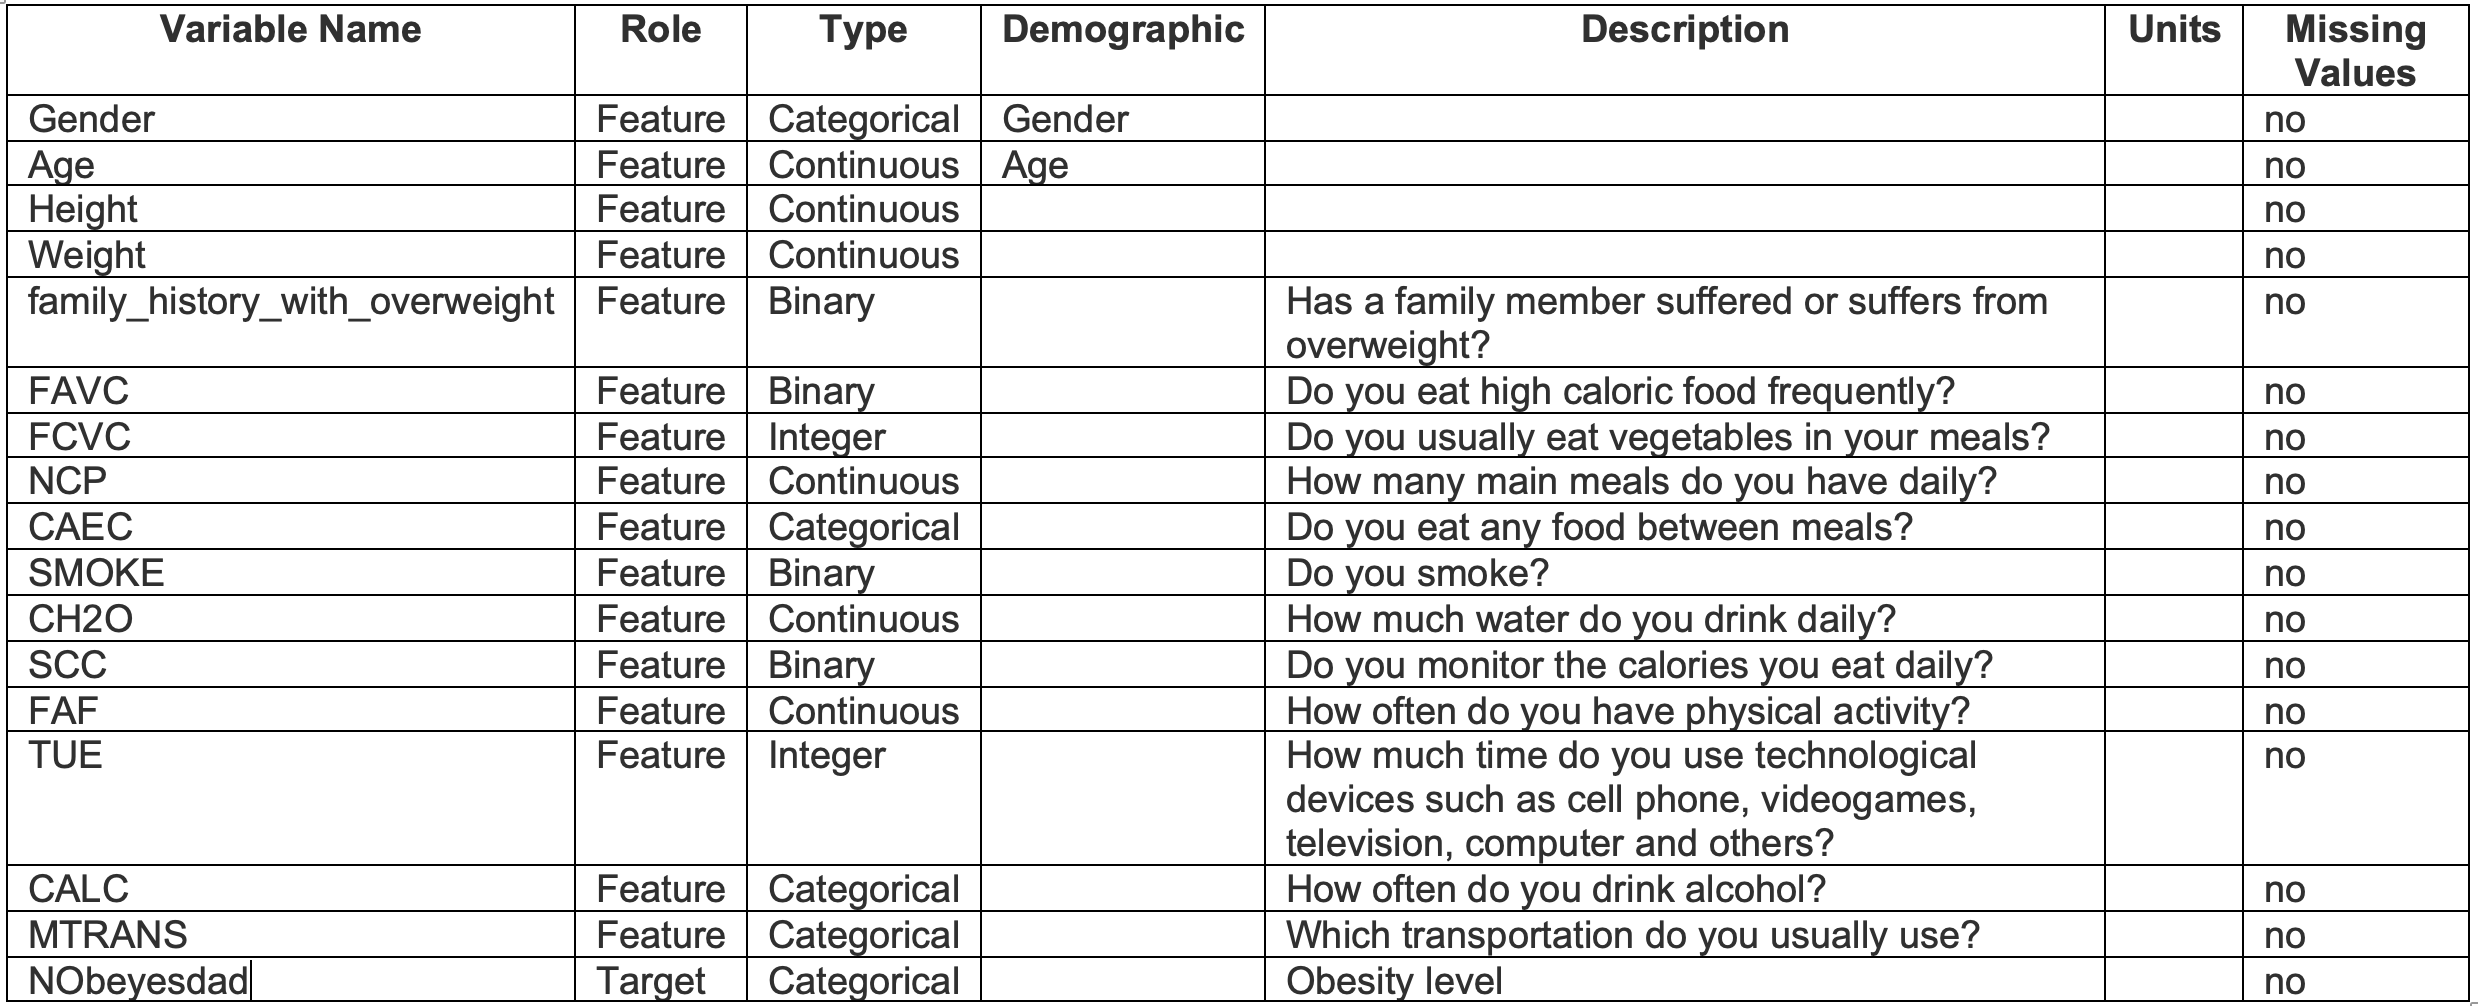

## 1.a Carga de datos y preprocesamiento

In [ ]:
# Importación de librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
#plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
sns.set_palette("deep")

### 1.a.1 (1 pt) Carguemos los datos

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# Cargar el dataset desde UCI
dataset = fetch_ucirepo(id=544)

# Variables predictoras y objetivo
X = dataset.data.features
y = dataset.data.targets

# Examina los primeros registros
df = pd.concat([X, y], axis=1)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### 1.a.2 (4 pts) Comente y visualice las distribuciones de cada atributo del dataset utilizando herramientas estadísticas básicas, boxplots e histogramas.

In [ ]:
# Estadísticas descriptivas básicas
df.describe(include='all')

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN


#Comentarios
NICO:En general, las variables poseen distintas escalas y niveles de dispersión, por lo que podría ser recomendable aplicar técnicas de normalización o estandarización antes de utilizar modelos de aprendizaje automático.

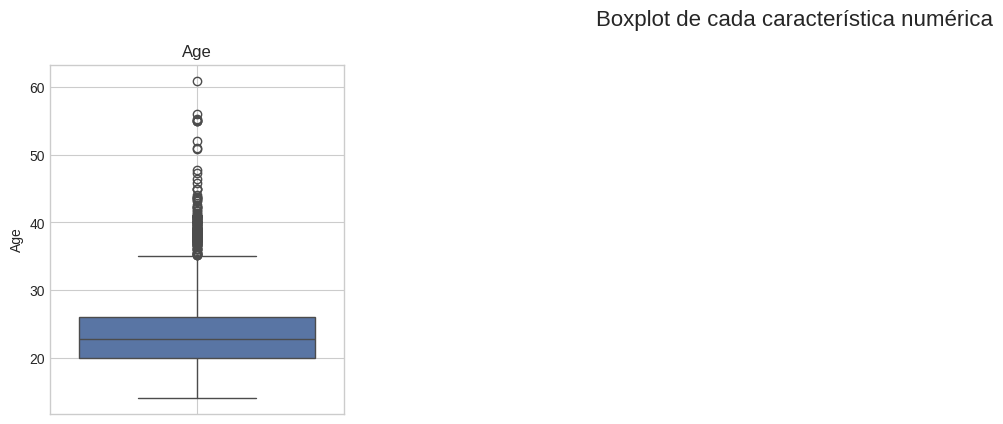

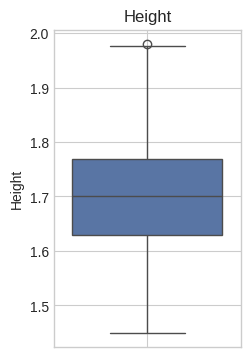

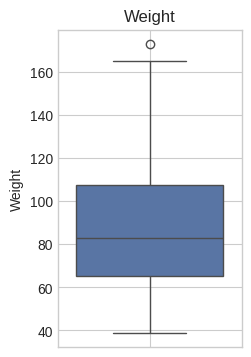

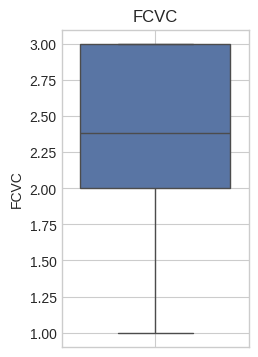

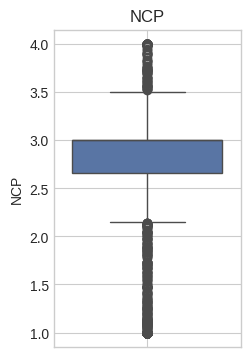

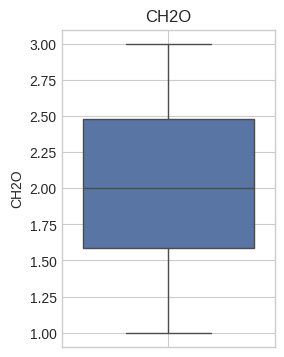

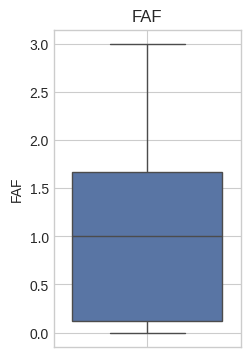

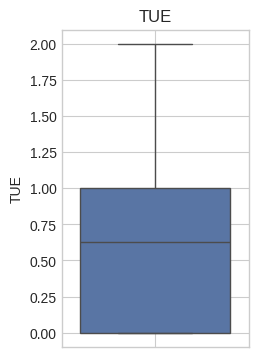

In [ ]:
# Boxplots de variables numéricas
# Selecciona solo las columnas numéricas para graficar
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(16, 8))
plt.suptitle('Boxplot de cada característica numérica', size=16)
for i, col in enumerate(num_cols):
  plt.subplot(2, 5, i+1)
  sns.boxplot(y=df[col])
  plt.title(col)
  plt.grid(True)
  plt.tight_layout()
  plt.show()

La variable Age presenta una distribución asimétrica positiva, concentrando la mayoría de los registros entre 18 y 30 años, aunque existen valores atípicos en edades mayores, lo cual se evidencia

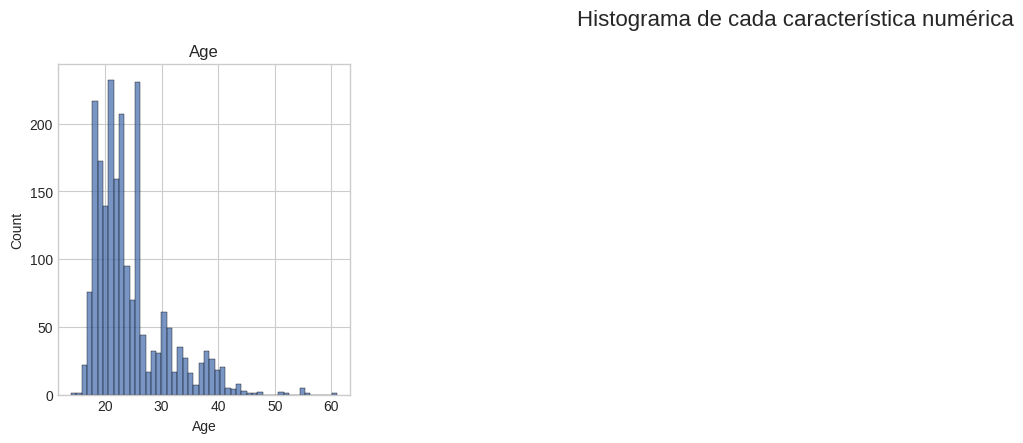

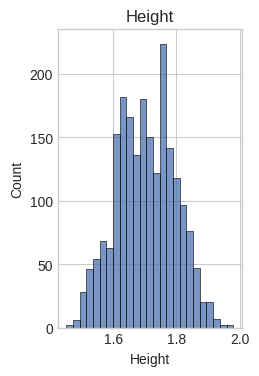

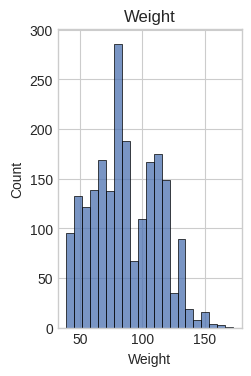

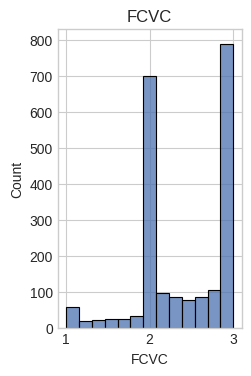

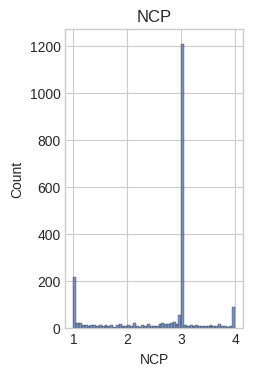

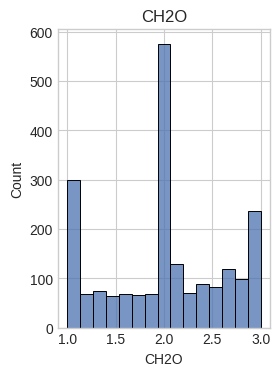

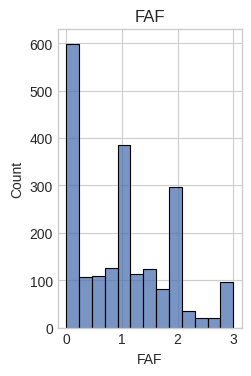

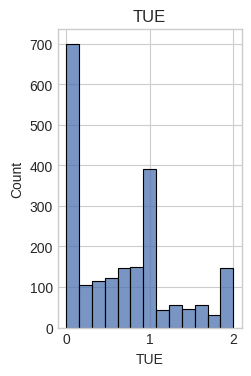

In [ ]:
# Histogramas de variables numéricas
# Puedes usar un enfoque similar al de los boxplots

plt.figure(figsize=(16, 8))
plt.suptitle('Histograma de cada característica numérica', size=16)
for i, col in enumerate(num_cols):
  plt.subplot(2, 5, i+1)
  sns.histplot(x=df[col])
  plt.title(col)
  plt.grid(True)
  plt.tight_layout()
  plt.show()

#En el caso de Weight, se observa una mayor variabilidad y una distribución más dispersa, además de algunos posibles valores extremos asociados a pesos elevados.
#En Height, se observa una distribución aproximadamente normal (simétrica), con una clara concentración alrededor de la media (~1.7 m), lo que indica baja variabilidad y comportamiento homogéneo.
#NCP presenta una fuerte concentración en el valor 3, indicando que la mayoría de los individuos consume un número similar de comidas principales.
#FAF y TUE muestran una alta concentración en valores bajos, lo que sugiere bajos niveles de actividad física y uso moderado de tecnología en gran parte de la muestra.
#CH2O presenta una distribución más equilibrada dentro de su rango, aunque sigue siendo discreta.

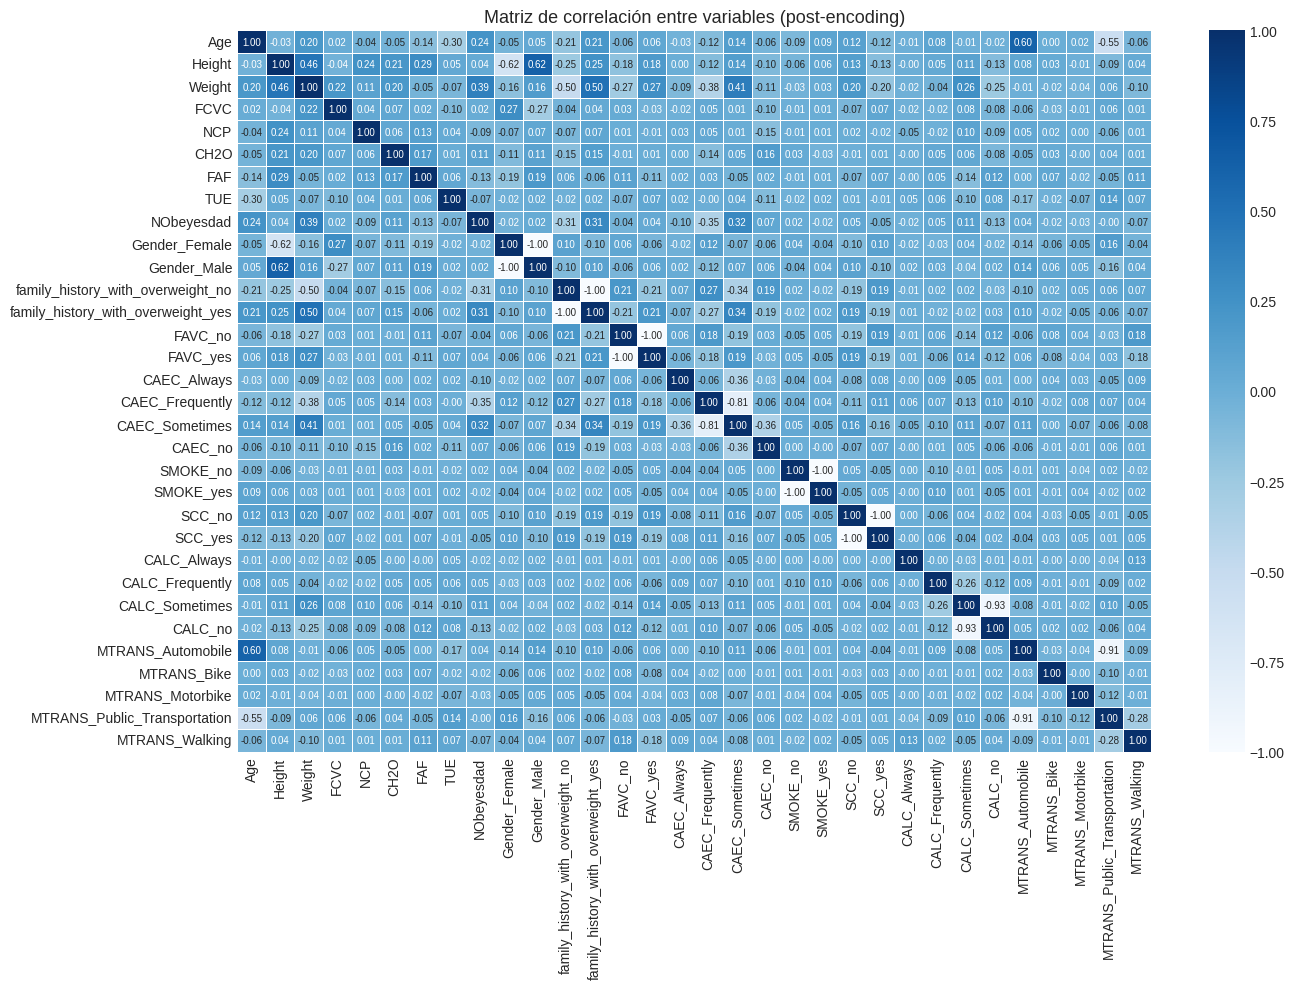

Correlación con NObeyesdad (ordenada por magnitud):
Weight                                0.388
CAEC_Frequently                      -0.352
CAEC_Sometimes                        0.317
family_history_with_overweight_no    -0.314
family_history_with_overweight_yes    0.314
Age                                   0.236
CALC_no                              -0.135
FAF                                  -0.130
CALC_Sometimes                        0.114
CH2O                                  0.109
CAEC_Always                          -0.099
NCP                                  -0.093
MTRANS_Walking                       -0.074
TUE                                  -0.069
CAEC_no                               0.067
SCC_no                                0.051
SCC_yes                              -0.051
CALC_Frequently                       0.047
FAVC_yes                              0.045
FAVC_no                              -0.045
MTRANS_Automobile                     0.041
Height                  

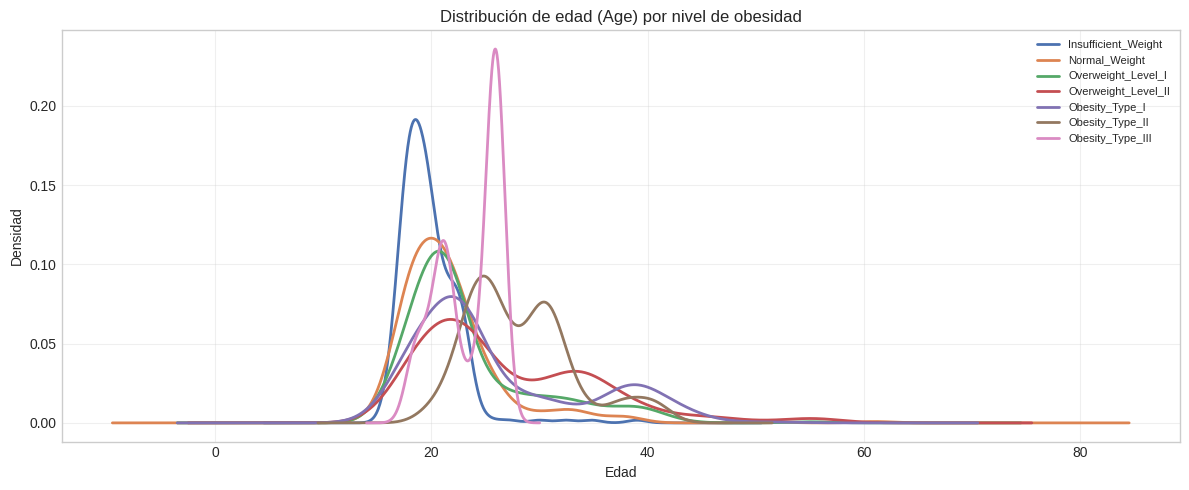

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# 1. Heatmap de correlación con el target
# ─────────────────────────────────────────────
corr_matrix = df_encoded.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Matriz de correlación entre variables (post-encoding)', fontsize=13)
plt.tight_layout()
plt.show()

# Ranking de correlación con el target
target_corr = corr_matrix['NObeyesdad'].drop('NObeyesdad').sort_values(key=abs, ascending=False)
print("Correlación con NObeyesdad (ordenada por magnitud):")
print(target_corr.round(3).to_string())

# ─────────────────────────────────────────────
# 2. KDE: distribución de Age por clase de obesidad
# ─────────────────────────────────────────────

# Recuperar etiquetas originales para legibilidad
df_plot = df.copy()  # df original sin encoding
class_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

plt.figure(figsize=(12, 5))
for cls in class_order:
    subset = df_plot[df_plot['NObeyesdad'] == cls]['Age']
    subset.plot.kde(label=cls, linewidth=2)

plt.title('Distribución de edad (Age) por nivel de obesidad')
plt.xlabel('Edad')
plt.ylabel('Densidad')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico KDE revela patrones etarios distintos según el nivel de obesidad. Insufficient_Weight concentra su densidad alrededor de los 20 años con un peak pronunciado y estrecho, lo que indica que el bajo peso es predominantemente un fenómeno de adultos jóvenes. Obesity_Type_III muestra el peak más alto y estrecho de todo el gráfico, centrado cerca de los 27 años, sugiriendo que la obesidad más severa se manifiesta en un rango etario muy específico y temprano. En contraste, Obesity_Type_I y Obesity_Type_II presentan distribuciones más planas y desplazadas hacia la derecha (35-45 años), indicando que estos niveles intermedios de obesidad son más frecuentes en adultos de mediana edad. Normal_Weight y los niveles de sobrepeso muestran distribuciones intermedias centradas entre 20-30 años.

### 1.a.3 (2 pts) Visualice la distribución de la variable objetivo. ¿Están las clases balanceadas?

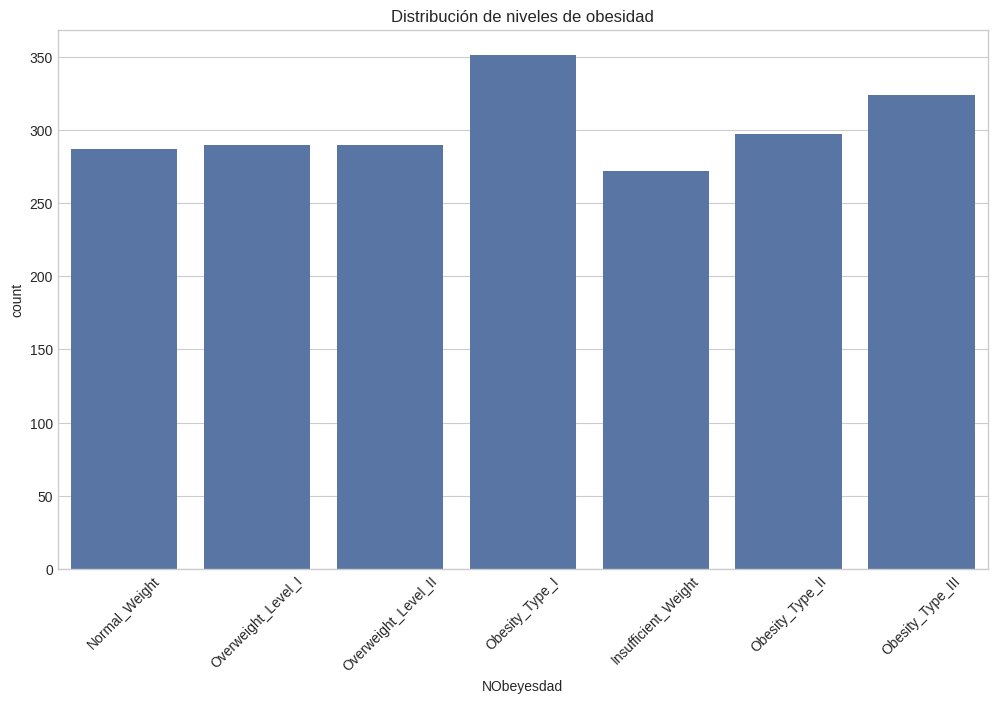

In [ ]:
# Graficar distribución de clases
sns.countplot(x=y['NObeyesdad'])
plt.title('Distribución de niveles de obesidad')
plt.xticks(rotation=45)
plt.show()

#El gráfico de barras de la variable objetivo NObeyesdad muestra la distribución de los distintos niveles de obesidad en el dataset.
#Se observa que las clases presentan frecuencias relativamente similares, sin que exista una categoría claramente dominante.
#Aunque algunas clases como Obesity_Type_I y Obesity_Type_III presentan una mayor cantidad de observaciones, y otras como Insufficient_Weight tienen una menor frecuencia, las diferencias no son lo suficientemente pronunciadas como para indicar un desbalance severo.

### 1.a.4 (2 pts) Codifique las variables categóricas usando LabelEncoder o pd.get_dummies según corresponda. Justifique su elección.

In [ ]:
# Copia del dataframe original
df_encoded = df.copy()

# Variables categóricas predictoras → One-Hot Encoding
# Se usa pd.get_dummies para evitar imponer orden artificial entre categorías nominales.
# LabelEncoder asigna enteros (0, 1, 2...) que la red puede interpretar como orden,
# lo que introduce un sesgo incorrecto en variables como CAEC, CALC o MTRANS.
cat_cols = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS'
]

df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=False, dtype=float)

# Codificar variable objetivo con LabelEncoder (correcto para clasificación multiclase)
from sklearn.preprocessing import LabelEncoder
le_target = LabelEncoder()
df_encoded['NObeyesdad'] = le_target.fit_transform(df_encoded['NObeyesdad'])

# Verificar resultado
print(f"Shape resultante: {df_encoded.shape}")
print(f"Columnas nuevas: {[c for c in df_encoded.columns if any(c.startswith(cat) for cat in cat_cols)]}")
df_encoded.head()

Shape resultante: (2111, 32)
Columnas nuevas: ['Gender_Female', 'Gender_Male', 'family_history_with_overweight_no', 'family_history_with_overweight_yes', 'FAVC_no', 'FAVC_yes', 'CAEC_Always', 'CAEC_Frequently', 'CAEC_Sometimes', 'CAEC_no', 'SMOKE_no', 'SMOKE_yes', 'SCC_no', 'SCC_yes', 'CALC_Always', 'CALC_Frequently', 'CALC_Sometimes', 'CALC_no', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad,Gender_Female,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,1,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,1,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,1,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,5,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,6,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


Se utilizó pd.get_dummies para codificar las variables categóricas predictoras, generando columnas binarias independientes por cada categoría. Esto evita imponer un orden artificial entre categorías nominales como MTRANS o CAEC, que con LabelEncoder recibirían enteros (0, 1, 2...) interpretables por la red como magnitudes con significado ordinal, introduciendo un sesgo incorrecto. Para la variable objetivo NObeyesdad se mantuvo LabelEncoder, lo cual es apropiado ya que sparse_categorical_crossentropy espera etiquetas enteras.

### 1.a.5 (3 pts) Separe el dataset en conjuntos de entrenamiento, validación y test, considerando un 70% de los datos para entrenamiento, un 20% para validación y un 10% para test.

In [ ]:
from sklearn.model_selection import train_test_split

# Separar variables predictoras (X) y variable objetivo (y)
X = df_encoded.drop('NObeyesdad', axis=1)
y = df_encoded['NObeyesdad']

# Paso 1: Separar el conjunto de prueba (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

# Paso 2: Separar entrenamiento (70%) y validación (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2/0.9, stratify=y_temp, random_state=42
)

# Verificar tamaños
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1476, 31)
Validation: (423, 31)
Test: (212, 31)


### 1.a.6 (2 pts) Verifique que el tamaño de los conjuntos se asemeje al indicado.

In [ ]:
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/X.shape[0]:.2%})")
print(f"Conjunto de validación: {X_val.shape[0]} muestras ({X_val.shape[0]/X.shape[0]:.2%})")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras ({X_test.shape[0]/X.shape[0]:.2%})")

Conjunto de entrenamiento: 1476 muestras (69.92%)
Conjunto de validación: 423 muestras (20.04%)
Conjunto de prueba: 212 muestras (10.04%)


#No da exactamente 70/20/10 porque el dataset tiene 2111 filas, y no se puede se puede dividir exacto

### 1.a.7 (3 pts) Estandarice las variables predictoras usando StandardScaler.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Crear el scaler
scaler_X = StandardScaler()

# Ajustar SOLO con entrenamiento y transformar
X_train_scaled = scaler_X.fit_transform(X_train)

# Transformar validación y test (sin volver a ajustar)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Verificar
print(X_train_scaled[:5])

[[-0.66954886  1.03662053 -0.06002699 -0.82285101  0.41256763  1.62652978
   1.16380612  0.54648148 -0.98787834  0.98787834 -0.46132245  0.46132245
   2.73546315 -2.73546315 -0.16035055 -0.36794648  0.4472136  -0.15122507
   0.14886459 -0.14886459  0.21976227 -0.21976227 -0.02603778 -0.18918106
   0.7092637  -0.65380896 -0.52298341 -0.05830136 -0.07382135  0.58360899
  -0.17733173]
 [-0.76732672 -0.74333666 -0.17532739  0.70204806  0.26043676 -1.65604136
  -1.17650383  1.1610249   1.0122704  -1.0122704  -0.46132245  0.46132245
  -0.36556881  0.36556881 -0.16035055 -0.36794648  0.4472136  -0.15122507
   0.14886459 -0.14886459  0.21976227 -0.21976227 -0.02603778 -0.18918106
   0.7092637  -0.65380896 -0.52298341 -0.05830136 -0.07382135  0.58360899
  -0.17733173]
 [ 0.26515745 -0.77927713  0.70243243  1.07022951  0.41256763  0.89743413
  -1.15682182 -0.13425399  1.0122704  -1.0122704  -0.46132245  0.46132245
  -0.36556881  0.36556881 -0.16035055 -0.36794648  0.4472136  -0.15122507
   0.148

### 1.a.8 (3 pts) ¿Cuál es la función de cada uno de estos conjuntos (train, validation, test)?

Conjunto de entrenamiento (train):
Se utiliza para ajustar los parámetros del modelo. Es el conjunto sobre el cual el algoritmo aprende los patrones presentes en los datos.

Conjunto de validación (validation):
Se utiliza para evaluar el desempeño del modelo durante el entrenamiento y ajustar hiperparámetros. Permite detectar problemas como el sobreajuste (overfitting) sin utilizar el conjunto de test.

Conjunto de prueba (test):
Se utiliza para evaluar el rendimiento final del modelo una vez entrenado. Este conjunto no participa en el entrenamiento ni en la validación, por lo que entrega una estimación objetiva del desempeño del modelo en datos no vistos.

### 1.a.9 (2 pts) Visualice la distribución de algunas variables antes y después de la estandarización.

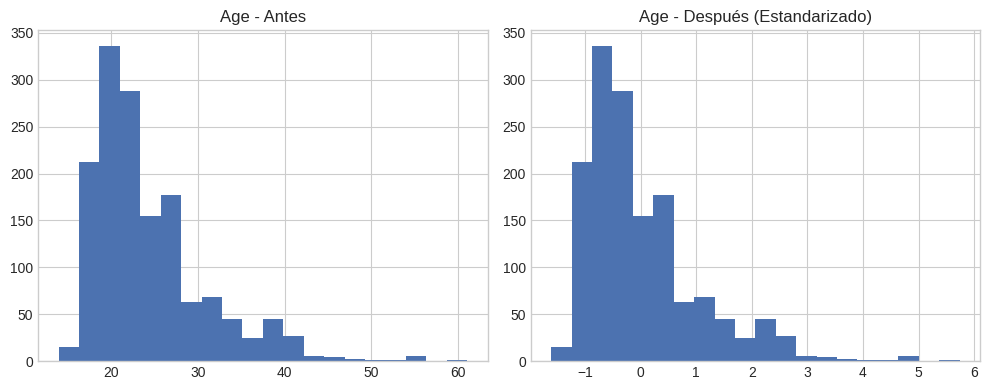

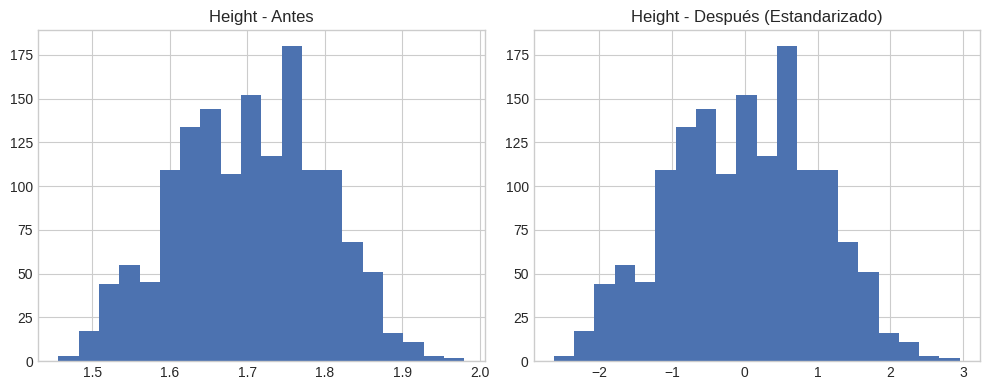

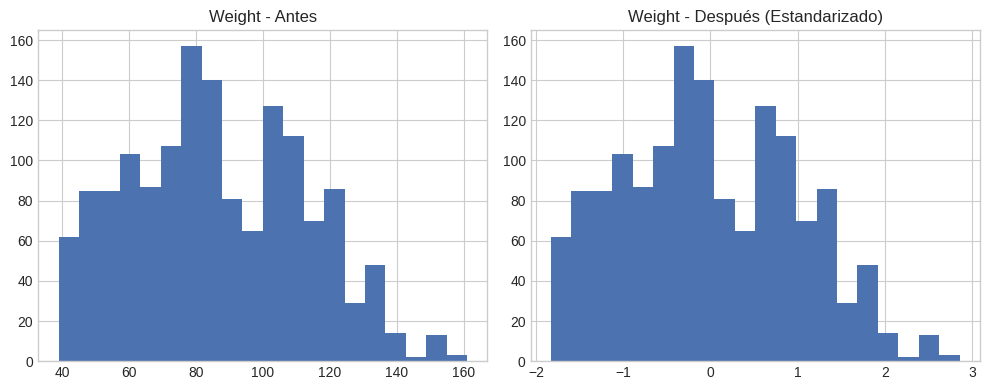

In [ ]:
# Convertir X_train_scaled a DataFrame para facilitar gráficos
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Seleccionar algunas variables (puedes cambiar estas)
cols = ['Age', 'Height', 'Weight']

# Histogramas antes vs después
for col in cols:
    plt.figure(figsize=(10,4))

    # Antes
    plt.subplot(1,2,1)
    plt.hist(X_train[col], bins=20)
    plt.title(f"{col} - Antes")
    plt.grid(True)

    # Después
    plt.subplot(1,2,2)
    plt.hist(X_train_scaled_df[col], bins=20)
    plt.title(f"{col} - Después (Estandarizado)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

La estandarización no modifica la forma de la distribución de las variables, sino que transforma su escala. A partir de los histogramas, se observa que las distribuciones mantienen su forma original (asimetría, concentración, etc.), pero ahora se encuentran centradas en torno a cero.

## 1.b Función para evaluar modelos

### 1.b.1 (2 pts) Importe las librerías necesarias para trabajar con redes neuronales.

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 791.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 145.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 107.0 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
!pip install tensorflow.keras

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers, activations, optimizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1, l2

# Verificar versión y dispositivos disponibles
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow version: 2.21.0
GPU disponible: []


### 1.b.2 (3 pts) Defina una función para calcular el F1-score macro en el conjunto de validación.

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

def calculate_f1(y_true, y_pred_probs):
    """
    Calcula el F1-score macro.

    Parámetros:
    y_true:       etiquetas reales
    y_pred_probs: probabilidades predichas por el modelo (salida del softmax)

    Retorna:
    F1-score macro
    """
    # Convertir probabilidades a clases (argmax)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Calcular F1-score macro
    f1 = f1_score(y_true, y_pred, average='macro')

    return f1

Se definió una función para calcular el F1-score macro a partir de las probabilidades predichas por el modelo. Dado que el modelo entrega probabilidades mediante una función softmax, se utilizó argmax para obtener la clase con mayor probabilidad como predicción final. Posteriormente, se calculó el F1-score utilizando el promedio macro, lo que permite evaluar el desempeño del modelo considerando todas las clases de manera equitativa.

## 1.c Búsqueda de hiperparámetros óptimos

### 1.c.1 (5 pts) Defina una función para entrenar y evaluar redes neuronales con diferentes arquitecturas e hiperparámetros.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

def train_evaluate_model(activation, depth, neurons, learning_rate, optimizer_name='SGD',
                         batch_size=32, initializer='glorot_uniform', dropout_rate=0,
                         regularizer_type=None, regularizer_lambda=0, epochs=500, patience=50):

    #  Regularización
    if regularizer_type == 'l1':
        reg = regularizers.l1(regularizer_lambda)
    elif regularizer_type == 'l2':
        reg = regularizers.l2(regularizer_lambda)
    else:
        reg = None

    # Construcción del modelo
    model = Sequential()

    # Capa de entrada + primera capa oculta
    model.add(Dense(neurons,
                    activation=activation,
                    kernel_initializer=initializer,
                    kernel_regularizer=reg,
                    input_shape=(X_train_scaled.shape[1],)))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Capas ocultas adicionales
    for _ in range(depth - 1):
        model.add(Dense(neurons,
                        activation=activation,
                        kernel_initializer=initializer,
                        kernel_regularizer=reg))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    #  Capa de salida
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))

    #  Optimizador
    if optimizer_name == 'SGD':
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'Adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'RMSprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

    #  Compilación
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )

    # Entrenamiento
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # Predicciones
    y_val_pred_probs = model.predict(X_val_scaled)
    y_test_pred_probs = model.predict(X_test_scaled)

    # F1-score
    val_f1 = calculate_f1(y_val, y_val_pred_probs)
    test_f1 = calculate_f1(y_test, y_test_pred_probs)

    return history, val_f1, test_f1, model

El modelo utiliza una capa de salida con función softmax para clasificación multiclase y la función de pérdida sparse_categorical_crossentropy. Además, se incorporó Early Stopping basado en el conjunto de validación para evitar sobreajuste.

Finalmente, el desempeño del modelo se evaluó utilizando el F1-score macro tanto en el conjunto de validación como en el de prueba.

### 1.c.2 (5 pts) Defina los espacios de búsqueda para cada hiperparámetro.

In [ ]:
# Espacios de búsqueda
activations_list  = ['relu', 'tanh']          # sigmoid descartado: converge muy lento
depths            = [2, 3, 4, 5]              # mínimo 2 capas para separar 7 clases
neurons_list      = [64, 128, 256]            # más capacidad representacional
learning_rates    = [0.001, 0.0003, 0.0001]   # Adam es sensible a lr altos

# Parámetros fijos para la búsqueda inicial
fixed_batch_size  = 32
fixed_initializer = 'glorot_uniform'
fixed_optimizer   = 'Adam'      # converge 5-10x más rápido que SGD en este problema
fixed_patience    = 20          # Adam converge antes, no necesita tanta paciencia

# Valores para estudios de ablación
depths_study         = [1, 2, 3, 4, 5, 6]
neurons_study        = [32, 64, 128, 256, 512]       # rango actualizado acorde al espacio de búsqueda
learning_rates_study = np.logspace(-5, -2, 8)        # rango acotado: lr > 0.01 es inestable con Adam
batch_sizes_study    = [16, 32, 64, 128, 256]

### 1.c.3 (10 pts) Realice una búsqueda sistemática de hiperparámetros usando un número limitado de trials aleatorios.

In [ ]:
import random

num_trials = 20
print(f"Realizando búsqueda con {num_trials} trials aleatorios")

results = []
best_f1 = -1
best_config = None

for i in range(num_trials):

    # Elegir hiperparámetros aleatorios
    activation = random.choice(activations_list)
    depth = random.choice(depths)
    neurons = random.choice(neurons_list)
    lr = random.choice(learning_rates)

    print(f"\nTrial {i+1}/{num_trials}")
    print(f"Config: act={activation}, depth={depth}, neurons={neurons}, lr={lr}")

    # Entrenar modelo
    history, val_f1, test_f1, model = train_evaluate_model(
        activation=activation,
        depth=depth,
        neurons=neurons,
        learning_rate=lr,
        optimizer_name=fixed_optimizer,
        batch_size=fixed_batch_size,
        initializer=fixed_initializer,
        epochs=200,
        patience=fixed_patience
    )

    # Guardar resultados
    results.append({
        'activation': activation,
        'depth': depth,
        'neurons': neurons,
        'learning_rate': lr,
        'val_f1': val_f1,
        'test_f1': test_f1
    })

    # Actualizar mejor modelo (según VALIDACIÓN)
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_config = results[-1]
        best_history = history
        best_model_keras = model

        print("Nuevo mejor modelo encontrado!")

# Mostrar mejor configuración
print("\n===== MEJOR CONFIGURACIÓN =====")
print(best_config)

Realizando búsqueda con 20 trials aleatorios

Trial 1/20
Config: act=relu, depth=2, neurons=64, lr=0.0001
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Nuevo mejor modelo encontrado!

Trial 2/20
Config: act=relu, depth=3, neurons=64, lr=0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Nuevo mejor modelo encontrado!

Trial 3/20
Config: act=relu, depth=4, neurons=64, lr=0.0003


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Trial 4/20
Config: act=tanh, depth=5, neurons=256, lr=0.0001


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Trial 19/20
Config: act=tanh, depth=2, neurons=128, lr=0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Trial 20/20
Config: act=tanh, depth=4, neurons=256, lr=0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

===== MEJOR CONFIGURACIÓN =====
{'activation': 'tanh', 'depth': 2, 'neurons': 256, 'learning_rate': 0.0003, 'val_f1': 0.9735375334325541, 'test_f1': 0.9616684060460495}


### 1.c.4 (5 pts) Analice los resultados y determine la mejor combinación de hiperparámetros.

In [ ]:
# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)

# Ordenar por F1-score de validación
results_df_sorted = results_df.sort_values(by='val_f1', ascending=False)

# Mostrar mejores modelos
results_df_sorted.head(10)

,activation,depth,neurons,learning_rate,val_f1,test_f1
10,tanh,2,256,0.0003,0.973538,0.961668
19,tanh,4,256,0.0001,0.971711,0.946934
5,tanh,4,128,0.0003,0.970956,0.941535
3,tanh,5,256,0.0001,0.966300,0.956666
8,tanh,3,128,0.0003,0.966269,0.952364
16,tanh,2,256,0.0010,0.966237,0.956645
7,tanh,5,256,0.0001,0.958736,0.946741
14,tanh,5,128,0.0010,0.956692,0.932020
18,tanh,2,128,0.0010,0.956579,0.956332
9,relu,3,256,0.0010,0.939522,0.932742


In [ ]:
best_model = results_df_sorted.iloc[0]

print("Mejor combinación de hiperparámetros:")
print(best_model)

Mejor combinación de hiperparámetros:
activation           tanh
depth                   2
neurons               256
learning_rate      0.0003
val_f1           0.973538
test_f1          0.961668
Name: 10, dtype: object


In [ ]:
# Promedio de F1 de validación por función de activación
print("F1 promedio por activación:")
display(results_df.groupby('activation')['val_f1'].mean().sort_values(ascending=False))

# Promedio de F1 de validación por profundidad
print("F1 promedio por profundidad:")
display(results_df.groupby('depth')['val_f1'].mean().sort_values(ascending=False))

# Promedio de F1 de validación por número de neuronas
print("F1 promedio por número de neuronas:")
display(results_df.groupby('neurons')['val_f1'].mean().sort_values(ascending=False))

# Promedio de F1 de validación por learning rate
print("F1 promedio por learning rate:")
display(results_df.groupby('learning_rate')['val_f1'].mean().sort_values(ascending=False))

F1 promedio por activación:


,val_f1
activation,
tanh,0.960425
relu,0.916645


F1 promedio por profundidad:


,val_f1
depth,
4,0.953589
5,0.941063
2,0.934362
3,0.930756


F1 promedio por número de neuronas:


,val_f1
neurons,
256,0.962674
128,0.944631
64,0.911749


F1 promedio por learning rate:


,val_f1
learning_rate,
0.0010,0.945131
0.0003,0.937340
0.0001,0.934077


### 1.c.5 (5 pts) Visualice el proceso de entrenamiento del mejor modelo encontrado.

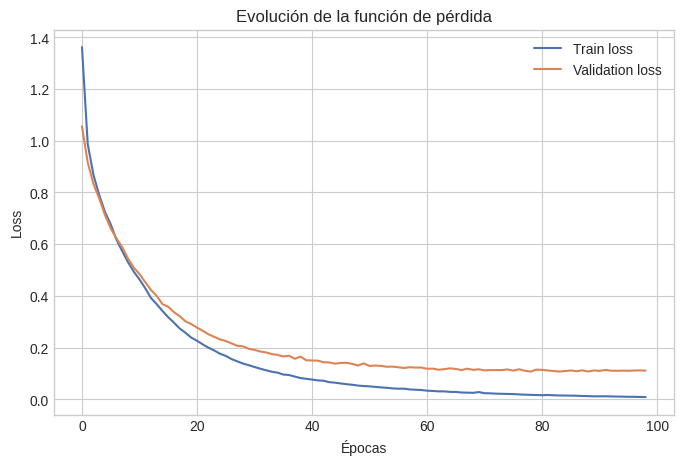

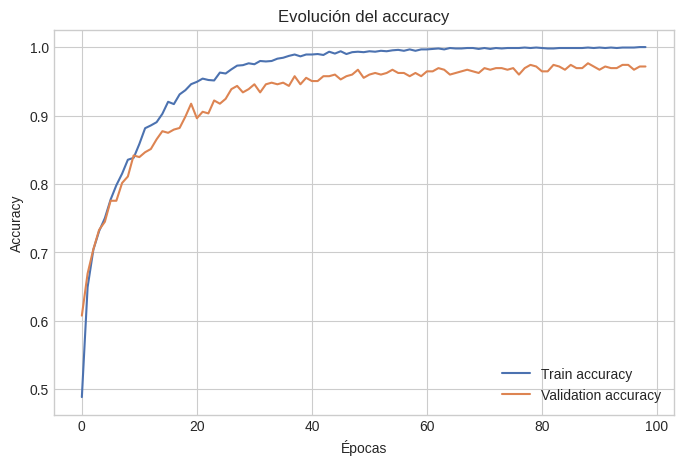

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
F1-score macro en test: 0.9617


<Figure size 800x600 with 0 Axes>

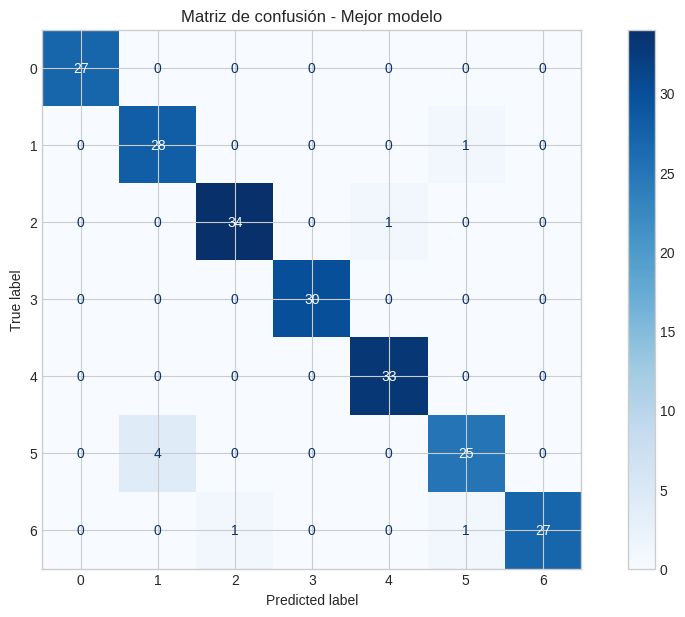

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Graficar evolución de loss y val_loss
plt.figure(figsize=(8,5))
plt.plot(best_history.history['loss'], label='Train loss')
plt.plot(best_history.history['val_loss'], label='Validation loss')
plt.title('Evolución de la función de pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Graficar evolución de accuracy y val_accuracy
plt.figure(figsize=(8,5))
plt.plot(best_history.history['accuracy'], label='Train accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation accuracy')
plt.title('Evolución del accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Predicciones en test
y_test_pred_probs = best_model_keras.predict(X_test_scaled)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

# F1-score en test
test_f1 = f1_score(y_test, y_test_pred, average='macro')
print(f"F1-score macro en test: {test_f1:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión - Mejor modelo')
plt.show()

La configuración ganadora fue una red de 2 capas ocultas con 256 neuronas, activación tanh, optimizador Adam y learning rate de 0.0003. Las curvas de entrenamiento muestran una convergencia rápida y limpia en menos de 100 épocas, con train loss cayendo a casi 0 y validation loss estabilizándose cerca de 0.11, evidenciando cierto overfitting leve pero controlado. La matriz de confusión confirma que el modelo clasifica correctamente casi todas las instancias en las 7 clases, con el único error relevante siendo 4 muestras de la clase 5 predichas como clase 1, lo que sugiere que esas dos categorías de obesidad comparten características similares que dificultan su separación incluso para un modelo bien ajustado.

## 1.d Estudios de ablación/sensibilidad (usando el mejor modelo como base)

### 1.d.1 (5 pts) Sensibilidad a la profundidad de la red: varíe el número de capas manteniendo los demás hiperparámetros óptimos.

Evaluando depth = 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando depth = 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando depth = 3


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Evaluando depth = 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Evaluando depth = 6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


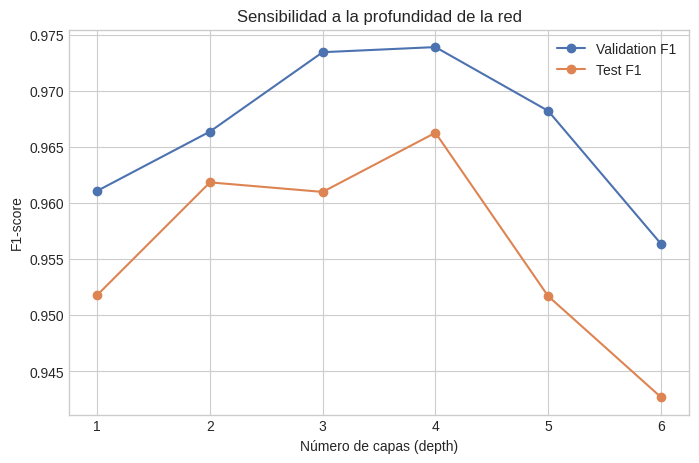

In [ ]:
# Extraer los mejores hiperparámetros encontrados
best_activation = best_config['activation']
best_neurons    = best_config['neurons']
best_lr         = best_config['learning_rate']

# Evaluar diferentes profundidades (depths_study)
# Almacenar resultados
depth_results = []

for d in depths_study:

    print(f"Evaluando depth = {d}")

    history, val_f1, test_f1, _ = train_evaluate_model(
        activation=best_activation,
        depth=d,
        neurons=best_neurons,
        learning_rate=best_lr,
        optimizer_name=fixed_optimizer,
        batch_size=fixed_batch_size,
        initializer=fixed_initializer,
        epochs=200,
        patience=fixed_patience
    )

    depth_results.append({
        'depth': d,
        'val_f1': val_f1,
        'test_f1': test_f1
    })
# Graficar profundidad vs F1-score
depth_df = pd.DataFrame(depth_results)

plt.figure(figsize=(8,5))
plt.plot(depth_df['depth'], depth_df['val_f1'], marker='o', label='Validation F1')
plt.plot(depth_df['depth'], depth_df['test_f1'], marker='o', label='Test F1')
plt.xlabel('Número de capas (depth)')
plt.ylabel('F1-score')
plt.title('Sensibilidad a la profundidad de la red')
plt.legend()
plt.grid(True)
plt.show()
# Discutir vanishing gradient si aparece

El experimento revela un comportamiento clásico de trade-off entre capacidad y generalización en función de la profundidad. El rendimiento mejora consistentemente desde 1 hasta 4 capas, donde alcanza su peak con F1 de validación de 0.974 y test de 0.967, confirmando que la red necesita suficiente profundidad para aprender las fronteras de decisión entre las 7 clases de obesidad. Sin embargo, a partir de las 5 capas el rendimiento cae de forma notable, especialmente en test (0.952 en 5 capas y 0.943 en 6 capas), mientras que validación cae más suavemente. Cabe destacar que incluso con 1 sola capa el modelo supera el 0.96 en validación, lo que refleja que la calidad del preprocesamiento (get_dummies + StandardScaler selectivo) y el optimizador Adam hacen un trabajo sólido independientemente de la arquitectura. La profundidad óptima para este problema es 4 capas, aunque 2-3 capas ofrecen un balance más conservador entre rendimiento y riesgo de sobreajuste.

### 1.d.2 (5 pts) Sensibilidad al número de neuronas: varíe el número de neuronas por capa manteniendo los demás hiperparámetros óptimos.

Evaluando neurons = 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando neurons = 64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando neurons = 128


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando neurons = 512


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,neurons,val_f1,test_f1
0,32,0.953904,0.942202
1,64,0.966265,0.961148
2,128,0.961180,0.956617
3,256,0.958634,0.961459
4,512,0.973965,0.961799


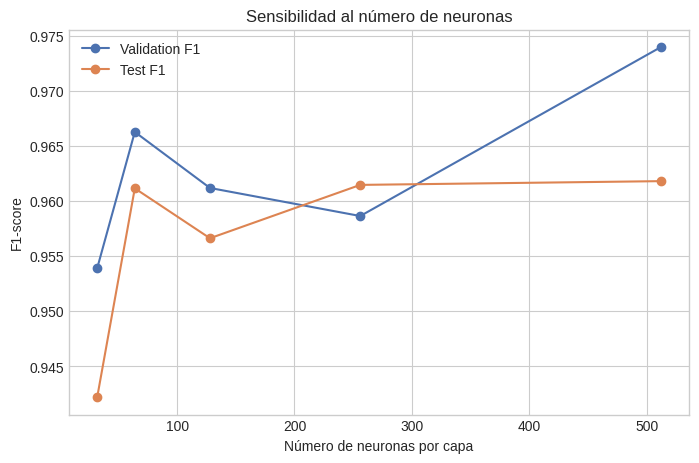

In [ ]:
# Sensibilidad al número de neuronas

neurons_results = []

for n in neurons_study:

    print(f"Evaluando neurons = {n}")

    history, val_f1, test_f1, _ = train_evaluate_model(
        activation=best_activation,
        depth=best_config['depth'],
        neurons=n,
        learning_rate=best_lr,
        optimizer_name=fixed_optimizer,
        batch_size=fixed_batch_size,
        initializer=fixed_initializer,
        epochs=200,
        patience=fixed_patience
    )

    neurons_results.append({
        'neurons': n,
        'val_f1': val_f1,
        'test_f1': test_f1
    })

# Convertir resultados a DataFrame
neurons_df = pd.DataFrame(neurons_results)

# Mostrar resultados
display(neurons_df)

# Graficar neuronas vs F1-score
plt.figure(figsize=(8,5))
plt.plot(neurons_df['neurons'], neurons_df['val_f1'], marker='o', label='Validation F1')
plt.plot(neurons_df['neurons'], neurons_df['test_f1'], marker='o', label='Test F1')

plt.xlabel('Número de neuronas por capa')
plt.ylabel('F1-score')
plt.title('Sensibilidad al número de neuronas')
plt.legend()
plt.grid(True)
plt.show()

El gráfico muestra un comportamiento más irregular que el de profundidad, lo que es característico de datasets de tamaño moderado donde la varianza entre experimentos es mayor. Con muy pocas neuronas (32), el modelo sufre underfitting severo, el test F1 cae a 0.943, indicando que la red no tiene capacidad suficiente para representar las 7 clases. El primer peak ocurre en 64 neuronas, con un buen balance entre validación (0.966) y test (0.962), sugiriendo que para este problema 64 neuronas ya captura la mayor parte de la estructura relevante. Entre 128 y 256 neuronas hay una zona de rendimiento irregular donde validación y test se comportan de forma inconsistente, probablemente por la aleatoriedad del entrenamiento interactuando con un dataset relativamente pequeño. A partir de 256 neuronas ambas curvas suben de forma más estable, alcanzando el peak en 512 neuronas con validación en 0.974, aunque el test se mantiene en 0.962. Esto sugiere que el punto de mayor eficiencia es 64 neuronas: agregar más capacidad mejora el ajuste en validación pero no se traduce en mejor generalización real, y además aumenta el costo computacional y el riesgo de sobreajuste en datasets más grandes.

### 1.d.3 (5 pts) Sensibilidad a la tasa de aprendizaje: varíe el learning rate manteniendo los demás hiperparámetros óptimos.

Evaluando learning rate = 0.00001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando learning rate = 0.00003


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando learning rate = 0.00007


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando learning rate = 0.01000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,learning_rate,val_f1,test_f1
0,0.000010,0.791937,0.817193
1,0.000027,0.907893,0.902747
2,0.000072,0.955914,0.947671
3,0.000193,0.973495,0.961984
4,0.000518,0.973717,0.966477
5,0.001389,0.971386,0.951771
6,0.003728,0.958571,0.951466
7,0.010000,0.937003,0.928671


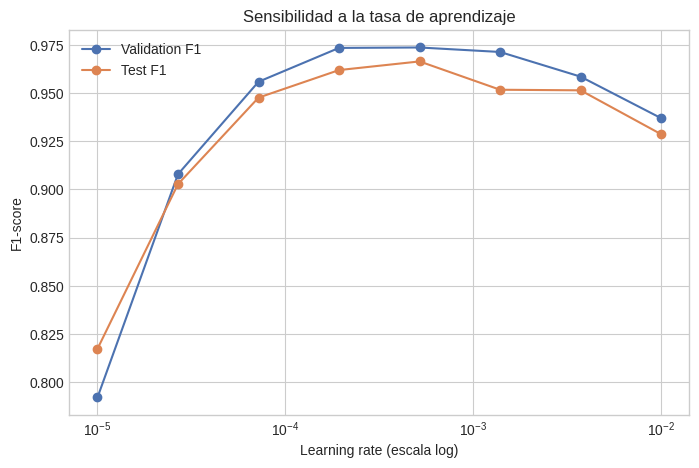

In [ ]:
# Sensibilidad al learning rate

lr_results = []

for lr in learning_rates_study:

    print(f"Evaluando learning rate = {lr:.5f}")

    history, val_f1, test_f1, _ = train_evaluate_model(
        activation=best_activation,
        depth=best_config['depth'],
        neurons=best_neurons,
        learning_rate=lr,
        optimizer_name=fixed_optimizer,
        batch_size=fixed_batch_size,
        initializer=fixed_initializer,
        epochs=200,
        patience=fixed_patience
    )

    lr_results.append({
        'learning_rate': lr,
        'val_f1': val_f1,
        'test_f1': test_f1
    })

# Convertir a DataFrame
lr_df = pd.DataFrame(lr_results)

# Mostrar resultados
display(lr_df)

# Graficar (IMPORTANTE: escala logarítmica)
plt.figure(figsize=(8,5))
plt.plot(lr_df['learning_rate'], lr_df['val_f1'], marker='o', label='Validation F1')
plt.plot(lr_df['learning_rate'], lr_df['test_f1'], marker='o', label='Test F1')

plt.xscale('log')  # clave
plt.xlabel('Learning rate (escala log)')
plt.ylabel('F1-score')
plt.title('Sensibilidad a la tasa de aprendizaje')
plt.legend()
plt.grid(True)
plt.show()

El gráfico exhibe la forma de campana asimétrica típica de la sensibilidad al learning rate en Adam, con un óptimo claro y degradación en ambos extremos por razones distintas. Para valores muy bajos (10⁻⁵), el modelo queda atrapado en las primeras etapas del descenso de gradiente y no converge dentro del número de épocas disponible, resultando en F1 cercano a 0.80, es underfitting por convergencia insuficiente, no por falta de capacidad. A medida que el lr aumenta, el rendimiento mejora rápidamente y ambas curvas se mantienen cercanas, indicando buena generalización. La zona óptima se encuentra entre 2×10⁻⁴ y 10⁻³, donde validación alcanza 0.974 y test se mantiene sobre 0.965, con un gap pequeño y estable entre ambas. A partir de 10⁻³ el rendimiento comienza a deteriorarse: el test cae más rápido que validación, señal de que pasos de actualización demasiado grandes generan inestabilidad en los pesos y peor generalización. En 10⁻² el modelo ya muestra degradación clara (test ~0.928), consistente con lo esperado para Adam donde lr altos causan oscilaciones alrededor del mínimo sin converger limpiamente. El learning rate óptimo de 0.0003 encontrado en el random search cae exactamente en el centro de esta zona estable, lo que valida retrospectivamente esa elección.

### 1.d.4 (5 pts) Sensibilidad al batch size: varíe el tamaño del batch manteniendo los demás hiperparámetros óptimos.

Evaluando batch size = 16


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando batch size = 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando batch size = 64


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando batch size = 1476


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,batch_size,val_f1,test_f1
0,16,0.973964,0.965839
1,32,0.963956,0.951561
2,64,0.963958,0.941900
3,128,0.951855,0.961668
4,256,0.966010,0.961449
5,1476,0.843552,0.845748


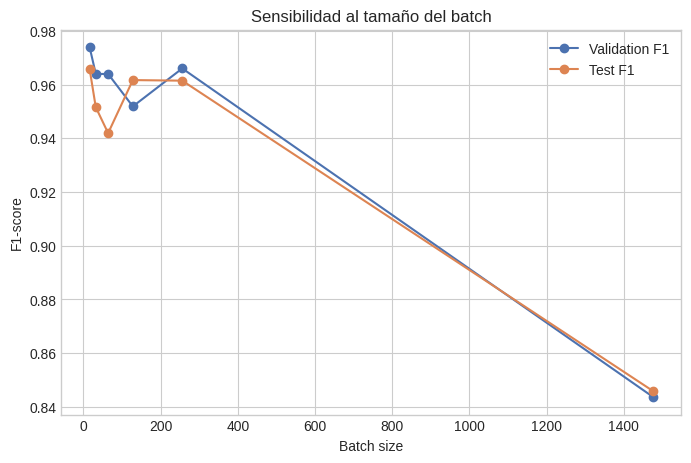

In [ ]:
# Sensibilidad al batch size

batch_results = []

# Agregar caso especial: batch size = tamaño total del conjunto de entrenamiento
batch_sizes_extended = batch_sizes_study + [X_train_scaled.shape[0]]

for bs in batch_sizes_extended:

    print(f"Evaluando batch size = {bs}")

    history, val_f1, test_f1, _ = train_evaluate_model(
        activation=best_activation,
        depth=best_config['depth'],
        neurons=best_neurons,
        learning_rate=best_lr,
        optimizer_name=fixed_optimizer,
        batch_size=bs,
        initializer=fixed_initializer,
        epochs=200,
        patience=fixed_patience
    )

    batch_results.append({
        'batch_size': bs,
        'val_f1': val_f1,
        'test_f1': test_f1
    })

# Convertir a DataFrame
batch_df = pd.DataFrame(batch_results)

# Mostrar resultados
display(batch_df)

# Graficar batch size vs F1-score
plt.figure(figsize=(8,5))
plt.plot(batch_df['batch_size'], batch_df['val_f1'], marker='o', label='Validation F1')
plt.plot(batch_df['batch_size'], batch_df['test_f1'], marker='o', label='Test F1')

plt.xlabel('Batch size')
plt.ylabel('F1-score')
plt.title('Sensibilidad al tamaño del batch')
plt.legend()
plt.grid(True)
plt.show()

El rendimiento cae monótonamente a medida que el batch size crece, con una caída especialmente pronunciada a partir de 256. Los batch sizes pequeños (16-64) logran los mejores resultados, con F1 sobre 0.96 en ambas curvas, y además presentan un comportamiento notable: validación y test están muy alineadas, indicando buena generalización sin sobreajuste. Esto se explica porque batches pequeños introducen ruido estocástico en el gradiente, lo que actúa como regularización implícita y ayuda al modelo a escapar de mínimos locales subóptimos. La ligera irregularidad entre 32 y 128 es normal dado el tamaño moderado del dataset. A partir de 256 el rendimiento cae de forma casi lineal en escala original, y el caso extremo de batch size igual al tamaño completo del conjunto de entrenamiento (gradient descent puro, ~1500 muestras) colapsa a 0.845. Otro aspecto destacable es que el gap entre validación y test prácticamente desaparece para batch sizes grandes, no porque mejore la generalización sino porque ambos empeoran igual. El batch size óptimo es 16-32, confirmando la elección original de 32 como valor fijo durante el random search.

### 1.d.5 (5 pts) Sensibilidad al optimizador: pruebe diferentes optimizadores manteniendo los demás hiperparámetros óptimos.

Evaluando optimizador: SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando optimizador: Adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando optimizador: RMSprop


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando optimizador: Adadelta


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,optimizer,val_f1,test_f1
0,SGD,0.657223,0.647500
1,Adam,0.966102,0.946743
2,RMSprop,0.966302,0.966923
3,Adagrad,0.637792,0.600009
4,Adadelta,0.657387,0.638547


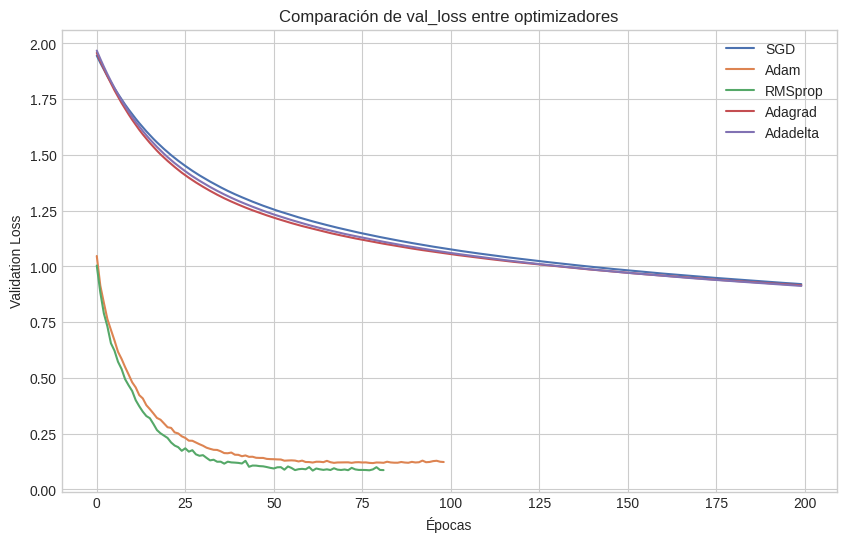

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta

optimizers_list = ['SGD', 'Adam', 'RMSprop', 'Adagrad', 'Adadelta']

opt_results = []
histories = {}

for opt in optimizers_list:

    print(f"Evaluando optimizador: {opt}")

    history, val_f1, test_f1, _ = train_evaluate_model(
        activation=best_activation,
        depth=best_config['depth'],
        neurons=best_neurons,
        learning_rate=best_lr,
        optimizer_name=opt,
        batch_size=fixed_batch_size,
        initializer=fixed_initializer,
        epochs=200,
        patience=fixed_patience
    )

    opt_results.append({
        'optimizer': opt,
        'val_f1': val_f1,
        'test_f1': test_f1
    })

    # Guardar history para comparar curvas
    histories[opt] = history

# Convertir a DataFrame
opt_df = pd.DataFrame(opt_results)

display(opt_df)
# Discutir diferencias observadas
plt.figure(figsize=(10,6))

for opt in optimizers_list:
    plt.plot(histories[opt].history['val_loss'], label=opt)

plt.title('Comparación de val_loss entre optimizadores')
plt.xlabel('Épocas')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Adam y RMSprop convergen en menos de 50 épocas a una val_loss cercana a 0.10, mientras que SGD, Adagrad y Adadelta nunca logran bajar de 0.93 en las 200 épocas disponibles. Esto confirma que los optimizadores con momento adaptativo son ampliamente superiores en este problema. RMSprop converge ligeramente más rápido en las primeras épocas pero Adam lo alcanza y estabiliza mejor al final, con menos oscilaciones. SGD, Adagrad y Adadelta se comportan de forma prácticamente idéntica aquí, lo que sugiere que el problema principal es la ausencia de adaptación por parámetro más que la falta de momento. La elección de Adam como optimizador fijo queda plenamente justificada.

### 1.d.6 (5 pts) Sensibilidad a la inicialización de pesos: pruebe diferentes inicializadores manteniendo los demás hiperparámetros óptimos.

Inicializador: glorot_uniform | Trial 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Inicializador: glorot_uniform | Trial 2/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Inicializador: glorot_uniform | Trial 3/3


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Inicializador: zeros | Trial 3/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,initializer,trial,val_f1,test_f1
0,glorot_uniform,1,0.966215,0.961471
1,glorot_uniform,2,0.960516,0.947271
2,glorot_uniform,3,0.971416,0.971575
3,glorot_normal,1,0.976470,0.961668
4,glorot_normal,2,0.969103,0.961427
5,glorot_normal,3,0.963699,0.961688
6,he_uniform,1,0.915010,0.908743
7,he_uniform,2,0.904835,0.931574
8,he_uniform,3,0.900807,0.937018
9,he_normal,1,0.902342,0.922149


,initializer,mean_val_f1,std_val_f1,mean_test_f1,std_test_f1
0,glorot_normal,0.969757,0.006411,0.961595,0.000145
1,glorot_uniform,0.966049,0.005452,0.960106,0.012210
2,he_normal,0.907577,0.004533,0.912999,0.009272
3,he_uniform,0.906884,0.007320,0.925778,0.015002
4,random_normal,0.969772,0.003020,0.956259,0.004706
5,zeros,0.040568,0.000000,0.040486,0.000000


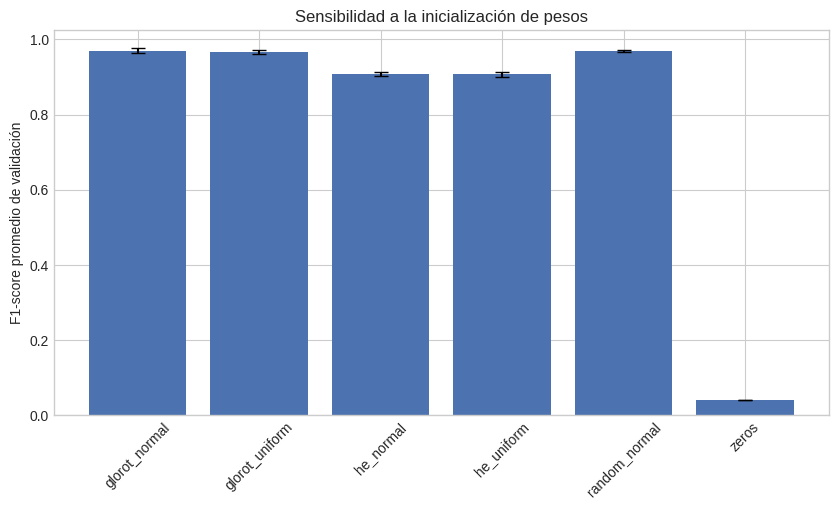

In [ ]:
# initializers_study = ['glorot_uniform', 'glorot_normal', 'he_uniform', 'he_normal', 'random_normal', 'zeros']
initializers_study = [
    'glorot_uniform',
    'glorot_normal',
    'he_uniform',
    'he_normal',
    'random_normal',
    'zeros'
]

n_trials_init = 3  # puedes subir a 5 si tienes tiempo

init_results = []

for init in initializers_study:
    for trial in range(n_trials_init):

        print(f"Inicializador: {init} | Trial {trial+1}/{n_trials_init}")

        history, val_f1, test_f1, _ = train_evaluate_model(
            activation=best_activation,
            depth=best_config['depth'],
            neurons=best_neurons,
            learning_rate=best_lr,
            optimizer_name=fixed_optimizer,
            batch_size=fixed_batch_size,
            initializer=init,
            epochs=200,
            patience=fixed_patience
        )

        init_results.append({
            'initializer': init,
            'trial': trial + 1,
            'val_f1': val_f1,
            'test_f1': test_f1
        })

init_df = pd.DataFrame(init_results)
display(init_df)
# Realizar múltiples trials para cada inicializador para evaluar variabilidad
# Incluir gráficos con barras de error
init_summary = init_df.groupby('initializer').agg(
    mean_val_f1=('val_f1', 'mean'),
    std_val_f1=('val_f1', 'std'),
    mean_test_f1=('test_f1', 'mean'),
    std_test_f1=('test_f1', 'std')
).reset_index()

display(init_summary)

plt.figure(figsize=(10,5))
plt.bar(
    init_summary['initializer'],
    init_summary['mean_val_f1'],
    yerr=init_summary['std_val_f1'],
    capsize=5
)

plt.xticks(rotation=45)
plt.ylabel('F1-score promedio de validación')
plt.title('Sensibilidad a la inicialización de pesos')
plt.grid(True)
plt.show()
# Discutir por qué algunos inicializadores funcionan mejor

Glorot (normal y uniform) y random_normal lideran con F1 ~0.97 y barras de error pequeñas, indicando convergencia estable y reproducible. He (normal y uniform) quedan en ~0.91, lo que tiene sentido: He está diseñado para activaciones ReLU y preserva la varianza asumiendo que la mitad de las neuronas se anulan, pero el modelo usa tanh, por lo que la escala de inicialización no es óptima. Zeros colapsa completamente a ~0.04.
La razón por la que Glorot funciona mejor que He con tanh es matemática: Glorot inicializa los pesos con varianza​, calibrada para mantener la varianza de las activaciones estable a través de capas con funciones simétricas como tanh. La elección original de glorot_uniform queda confirmada como óptima para esta arquitectura.

## 1.e Técnicas de regularización

### 1.e.1 (5 pts) Regularización L1 y L2: experimente con diferentes valores de lambda para regularización L1 y L2.

In [ ]:
from tensorflow.keras.regularizers import l1, l2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# IMPORTANTE: usar floats
lambdas = [0.0, 0.0001, 0.001, 0.01, 0.1]

reg_results = []

def get_model_weights(model):
    weights = []
    for layer in model.layers:
        if hasattr(layer, 'get_weights'):
            w = layer.get_weights()
            if len(w) > 0:
                weights.extend(w[0].flatten())
    return np.array(weights)

# Evaluar L1
for lam in lambdas:
    lam = float(lam)  # asegurar tipo float
    print(f"Evaluando L1 lambda = {lam}")

    history, val_f1, test_f1, model = train_evaluate_model(
        activation=best_activation,
        depth=best_config['depth'],
        neurons=best_neurons,
        learning_rate=best_lr,
        optimizer_name=fixed_optimizer,
        batch_size=fixed_batch_size,
        initializer=fixed_initializer,
        regularizer_type='l1',
        regularizer_lambda=lam,  # ya es float
        epochs=200,
        patience=fixed_patience
    )

    weights = get_model_weights(model)
    sparsity = np.mean(np.abs(weights) < 1e-4) * 100

    reg_results.append({
        'regularizer': 'L1',
        'lambda': lam,
        'val_f1': val_f1,
        'test_f1': test_f1,
        'sparsity_%': sparsity,
        'l2_norm': np.linalg.norm(weights)
    })

# Evaluar L2
for lam in lambdas:
    lam = float(lam)  # asegurar tipo float
    print(f"Evaluando L2 lambda = {lam}")

    history, val_f1, test_f1, model = train_evaluate_model(
        activation=best_activation,
        depth=best_config['depth'],
        neurons=best_neurons,
        learning_rate=best_lr,
        optimizer_name=fixed_optimizer,
        batch_size=fixed_batch_size,
        initializer=fixed_initializer,
        regularizer_type='l2',
        regularizer_lambda=lam,  # ya es float
        epochs=200,
        patience=fixed_patience
    )

    weights = get_model_weights(model)

    reg_results.append({
        'regularizer': 'L2',
        'lambda': lam,
        'val_f1': val_f1,
        'test_f1': test_f1,
        'sparsity_%': np.mean(np.abs(weights) < 1e-4) * 100,
        'l2_norm': np.linalg.norm(weights)
    })

reg_df = pd.DataFrame(reg_results)
display(reg_df)

Evaluando L1 lambda = 0.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando L1 lambda = 0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando L1 lambda = 0.001


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando L2 lambda = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,regularizer,lambda,val_f1,test_f1,sparsity_%,l2_norm
0,L1,0.0000,0.958615,0.961447,0.090349,23.724686
1,L1,0.0001,0.971054,0.965979,20.834662,16.054142
2,L1,0.0010,0.971639,0.945421,74.031409,16.279877
3,L1,0.0100,0.940418,0.939574,95.022853,16.191574
4,L1,0.1000,0.040568,0.040486,96.174798,3.809457
5,L2,0.0000,0.961508,0.951771,0.086363,23.238276
6,L2,0.0001,0.974007,0.970844,0.131537,18.470150
7,L2,0.0010,0.970961,0.956394,0.476988,14.658604
8,L2,0.0100,0.966164,0.940703,2.655984,17.195553
9,L2,0.1000,0.914663,0.921502,19.572438,27.930620


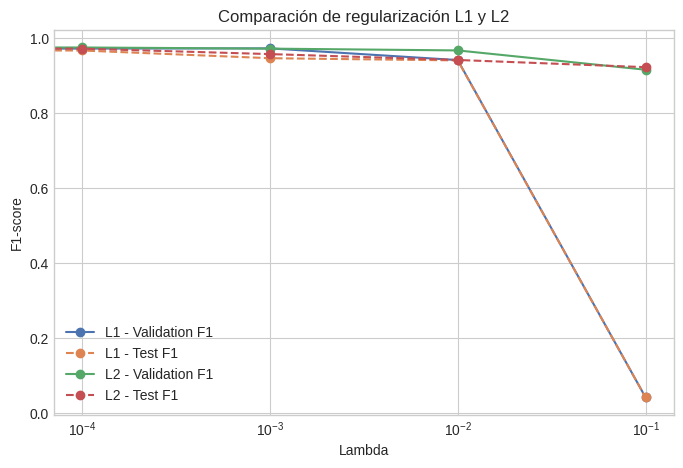

In [ ]:
plt.figure(figsize=(8,5))

for reg in ['L1', 'L2']:
    temp = reg_df[reg_df['regularizer'] == reg]
    plt.plot(temp['lambda'], temp['val_f1'], marker='o', label=f'{reg} - Validation F1')
    plt.plot(temp['lambda'], temp['test_f1'], marker='o', linestyle='--', label=f'{reg} - Test F1')

plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('F1-score')
plt.title('Comparación de regularización L1 y L2')
plt.legend()
plt.grid(True)
plt.show()

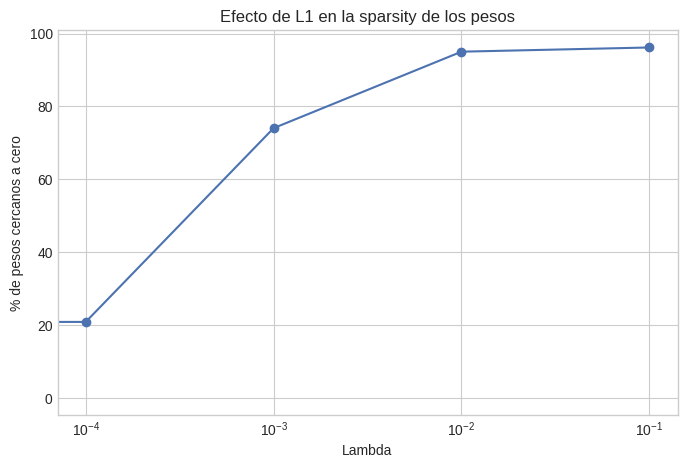

In [ ]:
l1_df = reg_df[reg_df['regularizer'] == 'L1']

plt.figure(figsize=(8,5))
plt.plot(l1_df['lambda'], l1_df['sparsity_%'], marker='o')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('% de pesos cercanos a cero')
plt.title('Efecto de L1 en la sparsity de los pesos')
plt.grid(True)
plt.show()

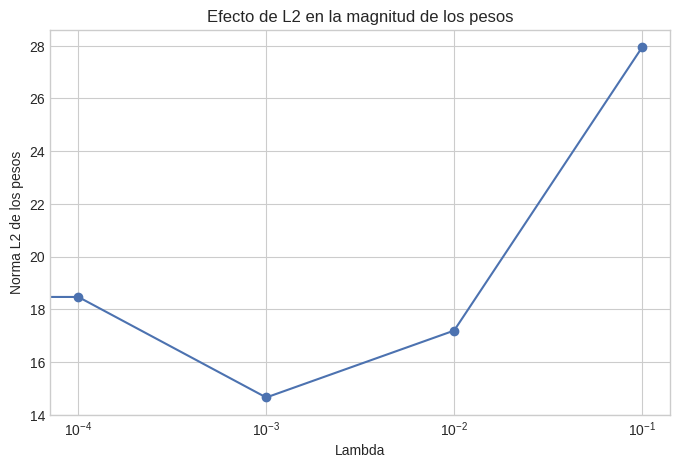

In [ ]:
l2_df = reg_df[reg_df['regularizer'] == 'L2']

plt.figure(figsize=(8,5))
plt.plot(l2_df['lambda'], l2_df['l2_norm'], marker='o')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Norma L2 de los pesos')
plt.title('Efecto de L2 en la magnitud de los pesos')
plt.grid(True)
plt.show()

El primer gráfico muestra que ambos tipos de regularización son efectivos en rangos bajos de lambda, manteniéndose sobre 0.96 de F1 hasta λ=10⁻³, sin brecha apreciable entre validación y test — señal de que el modelo base ya generaliza bien y la regularización es innecesaria en este caso. A partir de λ=10⁻² L1 colapsa abruptamente a ~0.05, mientras L2 cae más gradualmente a ~0.92, lo que refleja sus naturalezas distintas: L1 empuja pesos directamente a cero mediante el operador de umbralización suave, generando sparsity agresiva que destruye la capacidad del modelo cuando λ es grande, mientras L2 simplemente penaliza la magnitud, permitiendo una degradación más controlada.
El segundo gráfico confirma el efecto de sparsity de L1: con λ=10⁻⁴ ya el 21% de los pesos son cercanos a cero, y con λ=10⁻² ese porcentaje sube a 95%, explicando el colapso del F1. El tercer gráfico muestra algo contraintuitivo en L2: la norma de los pesos tiene un mínimo en λ=10⁻³ y luego sube en λ=10⁻¹, lo que ocurre porque una penalización muy fuerte distorsiona el paisaje de la loss y el optimizador converge a soluciones subóptimas con pesos grandes pero en direcciones distintas. El lambda óptimo es 10⁻⁴ para ambos, aunque dado que el modelo sin regularización ya no muestra overfitting significativo, la recomendación es omitirla o usar L2 con λ=10⁻⁴ como seguro conservador.

### 1.e.2 (5 pts) Dropout: experimente con diferentes tasas de dropout en las capas ocultas.

In [ ]:
dropout_rates = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

dropout_results = []
histories_dropout = {}

for dr in dropout_rates:

    print(f"Evaluando dropout = {dr}")

    history, val_f1, test_f1, _ = train_evaluate_model(
        activation=best_activation,
        depth=best_config['depth'],
        neurons=best_neurons,
        learning_rate=best_lr,
        optimizer_name=fixed_optimizer,
        batch_size=fixed_batch_size,
        initializer=fixed_initializer,
        dropout_rate=dr,
        epochs=200,
        patience=fixed_patience
    )

    # Últimos valores de accuracy
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    dropout_results.append({
        'dropout': dr,
        'val_f1': val_f1,
        'test_f1': test_f1,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'gap': train_acc - val_acc   #clave
    })

    histories_dropout[dr] = history

dropout_df = pd.DataFrame(dropout_results)
display(dropout_df)

Evaluando dropout = 0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Evaluando dropout = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando dropout = 0.2


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando dropout = 0.6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,dropout,val_f1,test_f1,train_acc,val_acc,gap
0,0.0,0.968844,0.967002,1.000000,0.966903,0.033097
1,0.1,0.976129,0.960740,0.996612,0.976359,0.020253
2,0.2,0.968925,0.961148,0.993225,0.969267,0.023958
3,0.3,0.973092,0.961197,0.988482,0.971631,0.016851
4,0.4,0.980763,0.945524,0.974255,0.978723,-0.004469
5,0.5,0.980348,0.945524,0.966125,0.976359,-0.010235
6,0.6,0.975819,0.949880,0.946477,0.971631,-0.025154


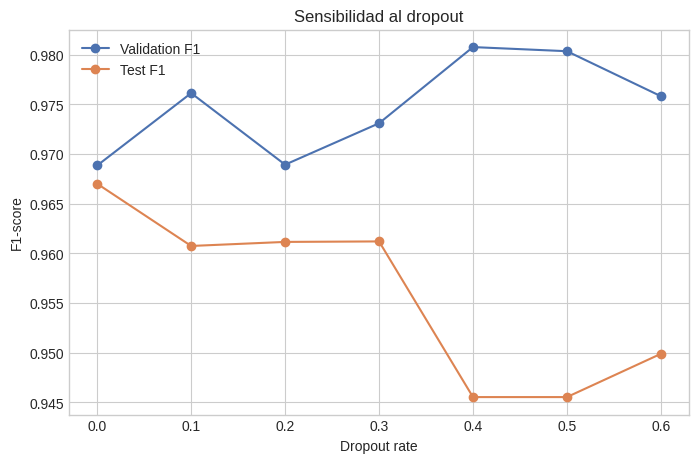

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(dropout_df['dropout'], dropout_df['val_f1'], marker='o', label='Validation F1')
plt.plot(dropout_df['dropout'], dropout_df['test_f1'], marker='o', label='Test F1')

plt.xlabel('Dropout rate')
plt.ylabel('F1-score')
plt.title('Sensibilidad al dropout')
plt.legend()
plt.grid(True)
plt.show()

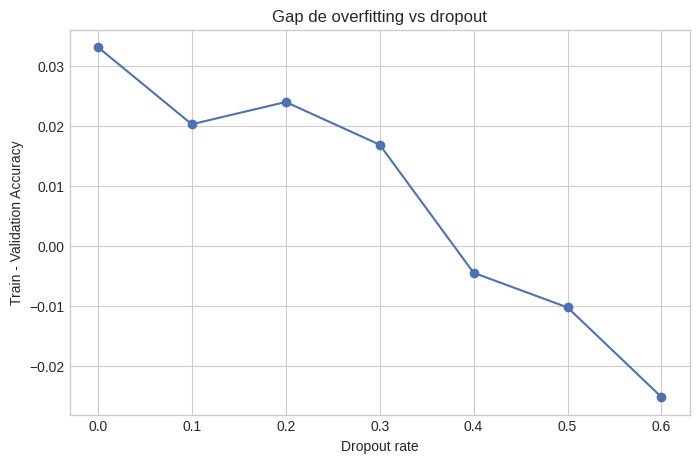

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(dropout_df['dropout'], dropout_df['gap'], marker='o')

plt.xlabel('Dropout rate')
plt.ylabel('Train - Validation Accuracy')
plt.title('Gap de overfitting vs dropout')
plt.grid(True)
plt.show()

Los gráficos revelan una tensión interesante entre validación y test que el segundo gráfico ayuda a interpretar. Con dropout=0 el gap train-validación es ~0.033, el mayor del experimento, confirmando overfitting leve. A medida que aumenta el dropout el gap se reduce y cruza cero en dropout=0.4, donde validación supera a train.
El problema está en que el test F1 colapsa desde 0.962 a 0.946 al pasar de dropout=0.3 a 0.4, mientras validación sigue subiendo hasta 0.981. Este gap creciente entre validación y test con dropout alto es una señal de que el modelo se está sobreajustando al conjunto de validación a través del early stopping, técnicamente no es overfitting clásico, sino que el criterio de parada favorece configuraciones que funcionan bien en validación pero no generalizan igual al test.
El dropout óptimo es 0.1-0.3: reduce el overfitting inicial sin penalizar la capacidad del modelo ni crear el falso optimismo de validación que aparece con tasas altas. Dado que el modelo base ya generaliza bien (gap pequeño sin dropout), tasas agresivas son contraproducentes en este problema de tamaño moderado.

### 1.e.3 (5 pts) Early Stopping: experimente con diferentes valores de paciencia.

In [ ]:
patience_values = [5, 10, 20, 50, 100]

patience_results = []

for p in patience_values:

    print(f"Evaluando patience = {p}")

    history, val_f1, test_f1, _ = train_evaluate_model(
        activation=best_activation,
        depth=best_config['depth'],
        neurons=best_neurons,
        learning_rate=best_lr,
        optimizer_name=fixed_optimizer,
        batch_size=fixed_batch_size,
        initializer=fixed_initializer,
        dropout_rate=0,
        regularizer_type=None,
        regularizer_lambda=0,
        epochs=500,
        patience=p
    )

    epochs_trained = len(history.history['loss'])

    patience_results.append({
        'patience': p,
        'epochs_trained': epochs_trained,
        'val_f1': val_f1,
        'test_f1': test_f1
    })

patience_df = pd.DataFrame(patience_results)
display(patience_df)

Evaluando patience = 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando patience = 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando patience = 20


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluando patience = 100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,patience,epochs_trained,val_f1,test_f1
0,5,80,0.970968,0.956645
1,10,103,0.968586,0.951573
2,20,100,0.971154,0.961692
3,50,142,0.966196,0.956257
4,100,192,0.973831,0.951794


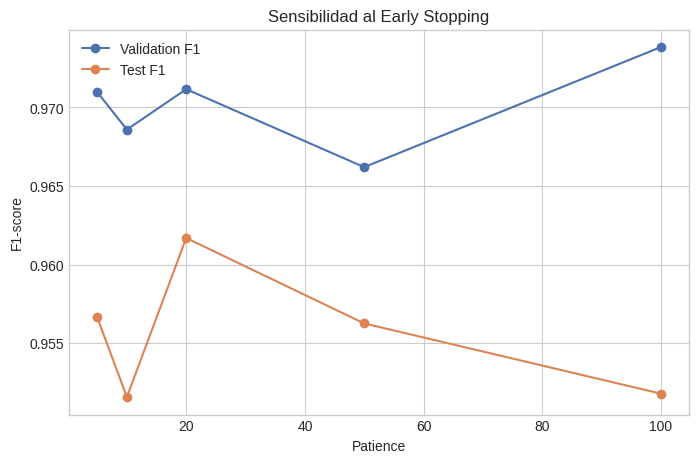

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(patience_df['patience'], patience_df['val_f1'], marker='o', label='Validation F1')
plt.plot(patience_df['patience'], patience_df['test_f1'], marker='o', label='Test F1')

plt.xlabel('Patience')
plt.ylabel('F1-score')
plt.title('Sensibilidad al Early Stopping')
plt.legend()
plt.grid(True)
plt.show()

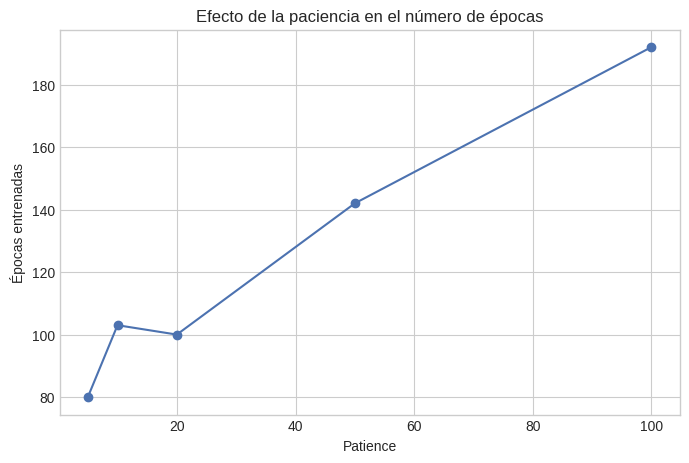

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(patience_df['patience'], patience_df['epochs_trained'], marker='o')

plt.xlabel('Patience')
plt.ylabel('Épocas entrenadas')
plt.title('Efecto de la paciencia en el número de épocas')
plt.grid(True)
plt.show()

Los gráficos muestran una paradoja aparente: validación mejora con patience alto (0.973 en patience=100) mientras test cae consistentemente a medida que se entrena más, alcanzando su mejor valor en patience=20 (0.962) y degradándose hacia 0.952 en patience=100. El segundo gráfico explica el mecanismo: mayor patience permite entrenar hasta ~190 épocas versus ~80 con patience=5, y ese entrenamiento extra beneficia la loss de validación pero introduce sobreajuste respecto al test real.
Esto es una manifestación del overfitting al conjunto de validación vía early stopping: cuando se entrena más épocas buscando el mínimo de val_loss, el modelo termina seleccionando pesos que funcionan bien específicamente para esa partición de validación, perdiendo generalización al test. Con patience muy bajo (5-10) el efecto contrario ocurre, el modelo para demasiado pronto y la alta varianza entre corridas genera resultados inestables, como se ve en el salto brusco entre patience=5 y patience=10 en ambas curvas.
El patience óptimo es 20: logra el mejor test F1 (0.962), entrena aproximadamente 100 épocas y mantiene el gap validación-test más pequeño del experimento, lo que indica que el criterio de parada es genuinamente representativo del rendimiento real del modelo.